## setup

In [1]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score, f1_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import random 
import copy

# Load feature arrays
X_list = []
for i in range(1, 10):
    X = np.load(fr"C:\Users\Hzaab\Desktop\intern\Data\X{i}.npy").astype(np.float32)
    X = X[:, None, :, :]      # Add channel dimension
    X_list.append(X)

# Combine into one dataset
X = np.concatenate(X_list, axis=0)

print("X shape:", X.shape)


# Load label arrays
y_list = []
for i in range(1, 10):
    y = np.load(fr"C:\Users\Hzaab\Desktop\intern\Data\X{i}L.npy")
    y_list.append(y)

# Combine labels
y = np.concatenate(y_list, axis=0)

print("y shape:", y.shape)


def evaluate(model, X, Y, params, batch_size=64):
    was_training = model.training
    model.eval()

    all_probs = []
    all_preds = []

    with torch.no_grad():
        for s in range(0, len(X), batch_size):
            e = min(s + batch_size, len(X))

            inputs = torch.from_numpy(X[s:e]).float()

            inputs = inputs.cuda(0)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(probs.argmax(dim=1).cpu().numpy())

    probs = np.concatenate(all_probs, axis=0)
    pred_labels = np.concatenate(all_preds, axis=0)


    results = []

    for param in params:
        if param == "acc":
            results.append(accuracy_score(Y, pred_labels))

        elif param == "auc":
            try:
                results.append(
                    roc_auc_score(
                        Y,
                        probs,
                        multi_class="ovo",
                        labels=np.arange(probs.shape[1])
                    )
                )
            except ValueError:
                results.append(None)

        elif param == "fmeasure":
            results.append(f1_score(Y, pred_labels, average="macro"))

    

    if was_training:
        model.train()
    else:
        model.eval()
    return results

X shape: (5184, 1, 22, 1001)
y shape: (5184,)


In [2]:
#input: (batch, 1, Chans, Samples)

class EEGNetTorch(nn.Module):
    def __init__(self, nb_classes=4, Chans=22, Samples=1001, dropoutRate=0.5, kernLength=125, F1=8, D=2, F2=16, dropoutType="Dropout"):
        super().__init__()

        DropoutLayer = nn.Dropout


        ##################################################Block 1#################################################
        #Conv2D: F1 filters, (1, kernLength) kernel size
        self.conv_temporal = nn.Conv2d(in_channels=1, out_channels=F1,
            kernel_size=(1, kernLength),
            padding="same", bias=False,
        )

        #BatchNormalization
        self.bn1 = nn.BatchNorm2d(F1, eps=1e-3, momentum=0.01)

        # DepthwiseConv2D: kernel size (chans, 1)
        self.conv_spatial = nn.Conv2d(in_channels=F1, out_channels=F1 * D,
            kernel_size=(Chans, 1),
            groups=F1, bias=False,
        )

        self.bn2 = nn.BatchNorm2d(F1 * D, eps=1e-3, momentum=0.01)

        #activation

        self.pool1 = nn.AvgPool2d(kernel_size=(1, 4))

        self.drop1 = DropoutLayer(dropoutRate)

        ##################################################Block 2#################################################

        #SeparableConv2D: (1,16) kernel size
        self.sepConv = nn.Conv2d(in_channels=F1 * D, out_channels=F1 * D,
            kernel_size=(1, 16),
            padding="same",
            groups=F1 * D, bias=False,
        )

        #SeparableConv2D: F2 filters, 
        self.sep_pointwise = nn.Conv2d(in_channels=F1 * D, out_channels=F2,
            kernel_size=(1, 1),
            bias=False,
        )

        self.bn3 = nn.BatchNorm2d(F2, eps=1e-3, momentum=0.01)
        self.pool2 = nn.AvgPool2d(kernel_size=(1, 8))
        self.drop2 = DropoutLayer(dropoutRate)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, Chans, Samples)
            out = self._features(dummy)
            self.flatten_dim = out.flatten(start_dim=1).shape[1]

        self.classifier = nn.Linear(self.flatten_dim, nb_classes)

    def _features(self, x):
        x = self.conv_temporal(x)
        x = self.bn1(x)

        x = self.conv_spatial(x)

        x = self.bn2(x)
        x = F.elu(x)
        x = self.pool1(x)
        x = self.drop1(x)

        x = self.sepConv(x)
        x = self.sep_pointwise(x)
        x = self.bn3(x)
        x = F.elu(x)
        x = self.pool2(x)
        x = self.drop2(x)

        return x

    def forward(self, x):
        x = self._features(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x

In [3]:
def _hide_EEG(X, mask_len, ch=[12, 13]):
    X = X.copy()
    
    rng = np.random.default_rng(42)

    n_trials, _, _, n_times = X.shape

    mask_len = min(mask_len, n_times)

    for trial in range(n_trials):
        start = rng.integers(0, n_times - mask_len + 1)
        X[trial, 0, ch, start:start + mask_len] = 0

    return X

In [4]:
batch_size = 32
num_epochs = 60
k = 9

skf = StratifiedKFold(
    n_splits=k,
    shuffle=True,
    random_state=42
)

X_cv = X
y_cv = y

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

nb_classes = len(np.unique(y_cv))
Chans = X_cv.shape[2]
Samples = X_cv.shape[3]

params = ["acc", "auc", "fmeasure"]

patience = 15
min_delta = 1e-4
fold_results = []

le = LabelEncoder()
y_cv = le.fit_transform(y).astype(np.int64)
X_cv = X.astype(np.float32)

## both



================ DURATION 50 ================

Fold 1/9


c:\Users\Hzaab\Desktop\intern\.venv\Lib\site-packages\torch\nn\modules\conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1091.)
  return F.conv2d(



Fold 1 Final Validation -
{'acc': 0.6354166666666666, 'auc': np.float64(0.8670749742798355), 'fmeasure': 0.6324837575206771}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6527777777777778, 'auc': np.float64(0.8768004115226339), 'fmeasure': 0.6468068874502207}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6267361111111112, 'auc': np.float64(0.8707521540637861), 'fmeasure': 0.6267558610491631}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6163194444444444, 'auc': np.float64(0.8594875257201645), 'fmeasure': 0.6172026201455576}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6371527777777778, 'auc': np.float64(0.8824990354938272), 'fmeasure': 0.6366577225749908}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6215277777777778, 'auc': np.float64(0.8597246334876543), 'fmeasure': 0.6222313240904677}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6076388888888888, 'auc': np.float64(0.8572691615226337), 'fmeasure': 0.6058715003104447}

Fold 8/9

Fold 8 Final Validation -
{'acc': 0.60763888888

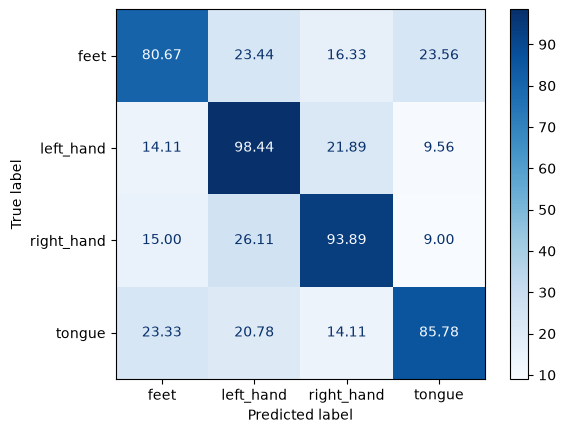



================ DURATION 100 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.625, 'auc': np.float64(0.868750803755144), 'fmeasure': 0.6235286953412918}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6302083333333334, 'auc': np.float64(0.8651379243827161), 'fmeasure': 0.6269517208342716}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6284722222222222, 'auc': np.float64(0.8644627700617283), 'fmeasure': 0.628595790987418}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6232638888888888, 'auc': np.float64(0.8595076195987655), 'fmeasure': 0.6202768706743004}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6302083333333334, 'auc': np.float64(0.8778332368827161), 'fmeasure': 0.6313645485814743}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6493055555555556, 'auc': np.float64(0.8698318544238685), 'fmeasure': 0.6496722644937682}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6128472222222222, 'auc': np.float64(0.8545042438271606), 'fmeasure': 0.6093857667012901}

Fold 8/9

Fol

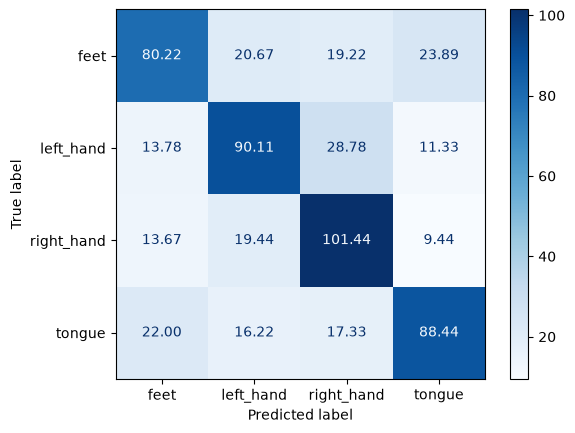



================ DURATION 150 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6215277777777778, 'auc': np.float64(0.8560353973765432), 'fmeasure': 0.6187110642132143}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6597222222222222, 'auc': np.float64(0.8843436535493826), 'fmeasure': 0.6563717569416938}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6145833333333334, 'auc': np.float64(0.8559992283950617), 'fmeasure': 0.6141388241388241}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6180555555555556, 'auc': np.float64(0.8579925411522633), 'fmeasure': 0.6178448220616894}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6666666666666666, 'auc': np.float64(0.8811246141975309), 'fmeasure': 0.6645442665412332}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6527777777777778, 'auc': np.float64(0.8688673482510288), 'fmeasure': 0.6516114604349899}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.5954861111111112, 'auc': np.float64(0.8514218428497943), 'fmeasure': 0.59528959935057}



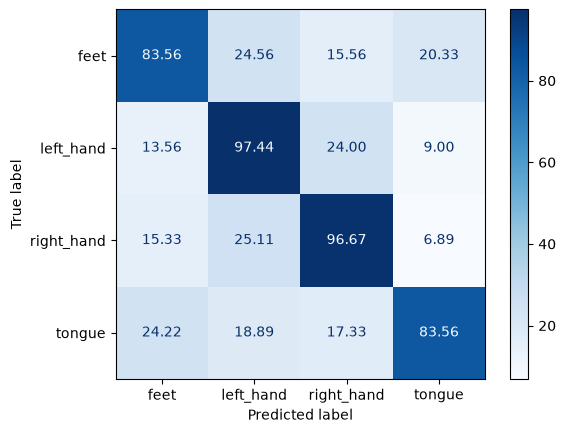



================ DURATION 200 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6510416666666666, 'auc': np.float64(0.881393872170782), 'fmeasure': 0.6499133293213044}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6336805555555556, 'auc': np.float64(0.8800757137345679), 'fmeasure': 0.62898321603176}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6354166666666666, 'auc': np.float64(0.8662993505658436), 'fmeasure': 0.6339031919454301}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6319444444444444, 'auc': np.float64(0.8651258680555555), 'fmeasure': 0.6323196813405878}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6423611111111112, 'auc': np.float64(0.8804816100823046), 'fmeasure': 0.6403726994011747}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.625, 'auc': np.float64(0.8739229681069959), 'fmeasure': 0.623441253188667}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.640625, 'auc': np.float64(0.8623770254629629), 'fmeasure': 0.6400169878430748}

Fold 8/9

Fold 8 Final Va

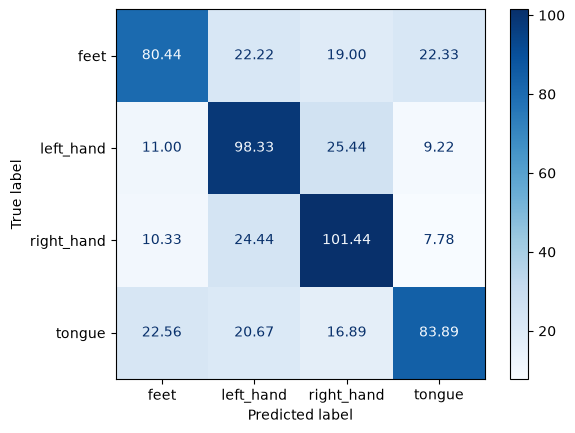

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

scale_results = {}
scale_conf_mats = {}

for duration in [50, 100, 150, 200]:

    print(f"\n\n================ DURATION {duration} ================")

    X_scaled = X_cv.copy()

    

    fold_results = []
    fold_conf_mats = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_scaled, y_cv), start=1):
        print(f"\nFold {fold}/{k}")

        X_tr, X_va = X_scaled[train_idx], X_scaled[valid_idx]
        y_tr, y_va = y_cv[train_idx], y_cv[valid_idx]
        X_tr= _hide_EEG(X_tr, duration)
        X_va= _hide_EEG(X_va, duration)



        train_ds = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long)
        )

        valid_ds = TensorDataset(
            torch.tensor(X_va, dtype=torch.float32),
            torch.tensor(y_va, dtype=torch.long)
        )

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

        net = EEGNetTorch(
            nb_classes=4,
            Chans=22,
            Samples=1001,
            kernLength=64,
            F1=32,
            D=4,
            F2=16,
            dropoutRate=0.4854763234903182,
        ).to(device)

        optimizer = torch.optim.Adam(
            net.parameters(),
            lr=0.0004102432506048275
        )

        criterion = torch.nn.CrossEntropyLoss()

        best_val_loss = float("inf")
        best_model_state = None
        epochs_without_improvement = 0

        for epoch in range(num_epochs):

            net.train()
            running_loss = 0.0
            n_seen = 0

            for inputs, labels in train_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad(set_to_none=True)
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                n_seen += inputs.size(0)

            train_loss = running_loss / n_seen
            #print("Training Loss", train_loss)

            net.eval()
            val_loss = 0.0
            val_seen = 0

            with torch.no_grad():
                for inputs, labels in valid_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * inputs.size(0)
                    val_seen += inputs.size(0)

            val_loss = val_loss / val_seen
            #print("Validation Loss", val_loss)

            #print("Train -", evaluate(net, X_tr, y_tr, params))
            #print("Validation -", evaluate(net, X_va, y_va, params))

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(net.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if best_model_state is not None:
            net.load_state_dict(best_model_state)

        metrics_raw = evaluate(net, X_va, y_va, params)

        if isinstance(metrics_raw, dict):
            metrics = metrics_raw
        else:
            metrics = dict(zip(params, metrics_raw))

        fold_results.append(metrics)

        # Confusion matrix for this fold
        net.eval()
        y_pred = []

        with torch.no_grad():
            X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
            outputs = net(X_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)

        cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3])
        fold_conf_mats.append(cm)

        print(f"\nFold {fold} Final Validation -")
        print(metrics)
        #print("Confusion Matrix:")
        #print(cm)

    print(f"\n========== Duration {duration} Cross-Validation Results ==========")

    avg_metrics = {}

    for metric in params:
        values = [result[metric] for result in fold_results]
        avg_metrics[metric] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
        print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

    avg_cm = np.mean(fold_conf_mats, axis=0)

    
    print("\nAverage Confusion Matrix:")
    print(avg_cm)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=avg_cm,
        display_labels=le.classes_
    )

    disp.plot(
        cmap="Blues",
        values_format=".2f"
    )

    plt.show()
    scale_results[duration] = avg_metrics
    scale_conf_mats[duration] = avg_cm

## train



================ DURATION 50 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.640625, 'auc': np.float64(0.8728499549897119), 'fmeasure': 0.6384240161563592}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6684027777777778, 'auc': np.float64(0.884010095164609), 'fmeasure': 0.6688101238976338}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6145833333333334, 'auc': np.float64(0.8651982060185185), 'fmeasure': 0.6129022051052211}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.65625, 'auc': np.float64(0.8769892939814815), 'fmeasure': 0.6541267179927099}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6440972222222222, 'auc': np.float64(0.8767843364197531), 'fmeasure': 0.6415726754852952}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.640625, 'auc': np.float64(0.8740113811728395), 'fmeasure': 0.6371969033872731}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6215277777777778, 'auc': np.float64(0.8608257780349794), 'fmeasure': 0.6197696621198375}

Fold 8/9

Fold 8 Final Validati

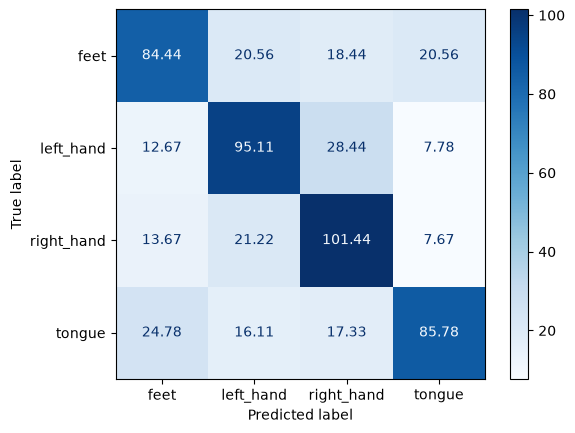



================ DURATION 100 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6579861111111112, 'auc': np.float64(0.8711379565329219), 'fmeasure': 0.6578517299507061}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6736111111111112, 'auc': np.float64(0.8908500514403291), 'fmeasure': 0.6754281368254625}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6076388888888888, 'auc': np.float64(0.8590012538580246), 'fmeasure': 0.6075616215698778}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6493055555555556, 'auc': np.float64(0.866773566100823), 'fmeasure': 0.6485506873441753}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6440972222222222, 'auc': np.float64(0.8742404513888888), 'fmeasure': 0.6415839888748416}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6458333333333334, 'auc': np.float64(0.8745941036522634), 'fmeasure': 0.6462466431673441}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.5902777777777778, 'auc': np.float64(0.8530615033436213), 'fmeasure': 0.5897547259776362}


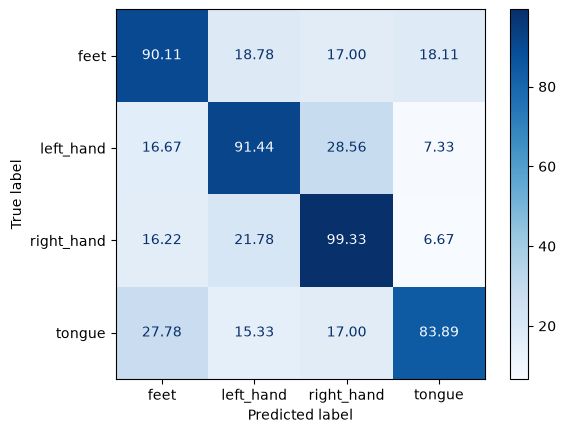



================ DURATION 150 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6354166666666666, 'auc': np.float64(0.8689838927469135), 'fmeasure': 0.6306352618369204}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6440972222222222, 'auc': np.float64(0.8753858024691357), 'fmeasure': 0.6424050969196092}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6024305555555556, 'auc': np.float64(0.8641774369855967), 'fmeasure': 0.6001981250494635}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6302083333333334, 'auc': np.float64(0.8583461934156378), 'fmeasure': 0.6293132802849133}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6302083333333334, 'auc': np.float64(0.866287294238683), 'fmeasure': 0.6292132483993507}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6267361111111112, 'auc': np.float64(0.866552533436214), 'fmeasure': 0.6267650148764279}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6215277777777778, 'auc': np.float64(0.8695907278806584), 'fmeasure': 0.6193190844196574}



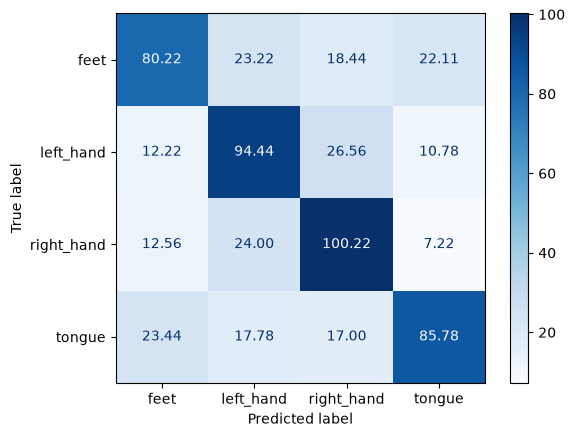



================ DURATION 200 ================

Fold 1/9


KeyboardInterrupt: 

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

scale_results = {}
scale_conf_mats = {}

for duration in [50, 100, 150, 200]:

    print(f"\n\n================ DURATION {duration} ================")

    X_scaled = X_cv.copy()

    

    fold_results = []
    fold_conf_mats = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_scaled, y_cv), start=1):
        print(f"\nFold {fold}/{k}")

        X_tr, X_va = X_scaled[train_idx], X_scaled[valid_idx]
        y_tr, y_va = y_cv[train_idx], y_cv[valid_idx]
        X_tr= _hide_EEG(X_tr, duration)



        train_ds = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long)
        )

        valid_ds = TensorDataset(
            torch.tensor(X_va, dtype=torch.float32),
            torch.tensor(y_va, dtype=torch.long)
        )

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

        net = EEGNetTorch(
            nb_classes=4,
            Chans=22,
            Samples=1001,
            kernLength=64,
            F1=32,
            D=4,
            F2=16,
            dropoutRate=0.4854763234903182,
        ).to(device)

        optimizer = torch.optim.Adam(
            net.parameters(),
            lr=0.0004102432506048275
        )

        criterion = torch.nn.CrossEntropyLoss()

        best_val_loss = float("inf")
        best_model_state = None
        epochs_without_improvement = 0

        for epoch in range(num_epochs):

            net.train()
            running_loss = 0.0
            n_seen = 0

            for inputs, labels in train_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad(set_to_none=True)
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                n_seen += inputs.size(0)

            train_loss = running_loss / n_seen
            #print("Training Loss", train_loss)

            net.eval()
            val_loss = 0.0
            val_seen = 0

            with torch.no_grad():
                for inputs, labels in valid_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * inputs.size(0)
                    val_seen += inputs.size(0)

            val_loss = val_loss / val_seen
            #print("Validation Loss", val_loss)

            #print("Train -", evaluate(net, X_tr, y_tr, params))
            #print("Validation -", evaluate(net, X_va, y_va, params))

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(net.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if best_model_state is not None:
            net.load_state_dict(best_model_state)

        metrics_raw = evaluate(net, X_va, y_va, params)

        if isinstance(metrics_raw, dict):
            metrics = metrics_raw
        else:
            metrics = dict(zip(params, metrics_raw))

        fold_results.append(metrics)

        # Confusion matrix for this fold
        net.eval()
        y_pred = []

        with torch.no_grad():
            X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
            outputs = net(X_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)

        cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3])
        fold_conf_mats.append(cm)

        print(f"\nFold {fold} Final Validation -")
        print(metrics)
        #print("Confusion Matrix:")
        #print(cm)

    print(f"\n========== Duration {duration} Cross-Validation Results ==========")

    avg_metrics = {}

    for metric in params:
        values = [result[metric] for result in fold_results]
        avg_metrics[metric] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
        print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

    avg_cm = np.mean(fold_conf_mats, axis=0)

    
    print("\nAverage Confusion Matrix:")
    print(avg_cm)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=avg_cm,
        display_labels=le.classes_
    )

    disp.plot(
        cmap="Blues",
        values_format=".2f"
    )

    plt.show()
    scale_results[duration] = avg_metrics
    scale_conf_mats[duration] = avg_cm



================ DURATION 200 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6336805555555556, 'auc': np.float64(0.8563408243312757), 'fmeasure': 0.6285836842275324}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6631944444444444, 'auc': np.float64(0.8845204796810701), 'fmeasure': 0.6565722490190226}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6197916666666666, 'auc': np.float64(0.8586757330246914), 'fmeasure': 0.6194238922416089}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.625, 'auc': np.float64(0.8639564043209876), 'fmeasure': 0.6242291031875895}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6458333333333334, 'auc': np.float64(0.874682516718107), 'fmeasure': 0.6434549701512686}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6458333333333334, 'auc': np.float64(0.8685619212962963), 'fmeasure': 0.6454356800768127}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6267361111111112, 'auc': np.float64(0.8646195023148148), 'fmeasure': 0.6257251658284533}

Fold 8/9

Fo

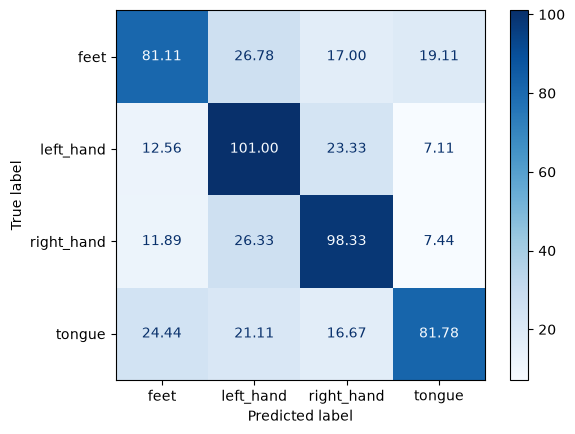

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

scale_results = {}
scale_conf_mats = {}

for duration in [200]:

    print(f"\n\n================ DURATION {duration} ================")

    X_scaled = X_cv.copy()

    

    fold_results = []
    fold_conf_mats = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_scaled, y_cv), start=1):
        print(f"\nFold {fold}/{k}")

        X_tr, X_va = X_scaled[train_idx], X_scaled[valid_idx]
        y_tr, y_va = y_cv[train_idx], y_cv[valid_idx]
        X_tr= _hide_EEG(X_tr, duration)



        train_ds = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long)
        )

        valid_ds = TensorDataset(
            torch.tensor(X_va, dtype=torch.float32),
            torch.tensor(y_va, dtype=torch.long)
        )

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

        net = EEGNetTorch(
            nb_classes=4,
            Chans=22,
            Samples=1001,
            kernLength=64,
            F1=32,
            D=4,
            F2=16,
            dropoutRate=0.4854763234903182,
        ).to(device)

        optimizer = torch.optim.Adam(
            net.parameters(),
            lr=0.0004102432506048275
        )

        criterion = torch.nn.CrossEntropyLoss()

        best_val_loss = float("inf")
        best_model_state = None
        epochs_without_improvement = 0

        for epoch in range(num_epochs):

            net.train()
            running_loss = 0.0
            n_seen = 0

            for inputs, labels in train_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad(set_to_none=True)
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                n_seen += inputs.size(0)

            train_loss = running_loss / n_seen
            #print("Training Loss", train_loss)

            net.eval()
            val_loss = 0.0
            val_seen = 0

            with torch.no_grad():
                for inputs, labels in valid_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * inputs.size(0)
                    val_seen += inputs.size(0)

            val_loss = val_loss / val_seen
            #print("Validation Loss", val_loss)

            #print("Train -", evaluate(net, X_tr, y_tr, params))
            #print("Validation -", evaluate(net, X_va, y_va, params))

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(net.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if best_model_state is not None:
            net.load_state_dict(best_model_state)

        metrics_raw = evaluate(net, X_va, y_va, params)

        if isinstance(metrics_raw, dict):
            metrics = metrics_raw
        else:
            metrics = dict(zip(params, metrics_raw))

        fold_results.append(metrics)

        # Confusion matrix for this fold
        net.eval()
        y_pred = []

        with torch.no_grad():
            X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
            outputs = net(X_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)

        cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3])
        fold_conf_mats.append(cm)

        print(f"\nFold {fold} Final Validation -")
        print(metrics)
        #print("Confusion Matrix:")
        #print(cm)

    print(f"\n========== Duration {duration} Cross-Validation Results ==========")

    avg_metrics = {}

    for metric in params:
        values = [result[metric] for result in fold_results]
        avg_metrics[metric] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
        print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

    avg_cm = np.mean(fold_conf_mats, axis=0)

    
    print("\nAverage Confusion Matrix:")
    print(avg_cm)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=avg_cm,
        display_labels=le.classes_
    )

    disp.plot(
        cmap="Blues",
        values_format=".2f"
    )

    plt.show()
    scale_results[duration] = avg_metrics
    scale_conf_mats[duration] = avg_cm

## test 

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

scale_results = {}
scale_conf_mats = {}

for duration in [50, 100, 150, 200]:

    print(f"\n\n================ DURATION {duration} ================")

    X_scaled = X_cv.copy()

    

    fold_results = []
    fold_conf_mats = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_scaled, y_cv), start=1):
        print(f"\nFold {fold}/{k}")

        X_tr, X_va = X_scaled[train_idx], X_scaled[valid_idx]
        y_tr, y_va = y_cv[train_idx], y_cv[valid_idx]
        X_va= _hide_EEG(X_va, duration)



        train_ds = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long)
        )

        valid_ds = TensorDataset(
            torch.tensor(X_va, dtype=torch.float32),
            torch.tensor(y_va, dtype=torch.long)
        )

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

        net = EEGNetTorch(
            nb_classes=4,
            Chans=22,
            Samples=1001,
            kernLength=64,
            F1=32,
            D=4,
            F2=16,
            dropoutRate=0.4854763234903182,
        ).to(device)

        optimizer = torch.optim.Adam(
            net.parameters(),
            lr=0.0004102432506048275
        )

        criterion = torch.nn.CrossEntropyLoss()

        best_val_loss = float("inf")
        best_model_state = None
        epochs_without_improvement = 0

        for epoch in range(num_epochs):

            net.train()
            running_loss = 0.0
            n_seen = 0

            for inputs, labels in train_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad(set_to_none=True)
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                n_seen += inputs.size(0)

            train_loss = running_loss / n_seen
            #print("Training Loss", train_loss)

            net.eval()
            val_loss = 0.0
            val_seen = 0

            with torch.no_grad():
                for inputs, labels in valid_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * inputs.size(0)
                    val_seen += inputs.size(0)

            val_loss = val_loss / val_seen
            #print("Validation Loss", val_loss)

            #print("Train -", evaluate(net, X_tr, y_tr, params))
            #print("Validation -", evaluate(net, X_va, y_va, params))

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(net.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if best_model_state is not None:
            net.load_state_dict(best_model_state)

        metrics_raw = evaluate(net, X_va, y_va, params)

        if isinstance(metrics_raw, dict):
            metrics = metrics_raw
        else:
            metrics = dict(zip(params, metrics_raw))

        fold_results.append(metrics)

        # Confusion matrix for this fold
        net.eval()
        y_pred = []

        with torch.no_grad():
            X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
            outputs = net(X_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)

        cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3])
        fold_conf_mats.append(cm)

        print(f"\nFold {fold} Final Validation -")
        print(metrics)
        #print("Confusion Matrix:")
        #print(cm)

    print(f"\n========== Duration {duration} Cross-Validation Results ==========")

    avg_metrics = {}

    for metric in params:
        values = [result[metric] for result in fold_results]
        avg_metrics[metric] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
        print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

    avg_cm = np.mean(fold_conf_mats, axis=0)

    
    print("\nAverage Confusion Matrix:")
    print(avg_cm)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=avg_cm,
        display_labels=le.classes_
    )

    disp.plot(
        cmap="Blues",
        values_format=".2f"
    )

    plt.show()
    scale_results[duration] = avg_metrics
    scale_conf_mats[duration] = avg_cm



================ DURATION 50 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6649305555555556, 'auc': np.float64(0.882177533436214), 'fmeasure': 0.6629186361054412}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6701388888888888, 'auc': np.float64(0.8866584683641975), 'fmeasure': 0.6696380593822195}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6128472222222222, 'auc': np.float64(0.8538933899176954), 'fmeasure': 0.6087762648074363}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6145833333333334, 'auc': np.float64(0.8490306712962963), 'fmeasure': 0.6141364299027587}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6197916666666666, 'auc': np.float64(0.8703060699588477), 'fmeasure': 0.6170145822883839}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.5972222222222222, 'auc': np.float64(0.8562443737139919), 'fmeasure': 0.5913576555023924}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6458333333333334, 'auc': np.float64(0.8663515946502057), 'fmeasure': 0.6431860380401826}



KeyboardInterrupt: 